<a href="https://colab.research.google.com/github/GuillermoUribe03/Coffee-Quality-Project/blob/main/Final_modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# imports de librerias


In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import kagglehub
from kagglehub import KaggleDatasetAdapter

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

# import dataset de kagle


In [214]:
file_path = "arabica_data_cleaned.csv"

df_raw = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "volpatto/coffee-quality-database-from-cqi",
  file_path,
)

Using Colab cache for faster access to the 'coffee-quality-database-from-cqi' dataset.


# Análisis exploratorio de los datos

### Filtrar las variables seleccionadas (excluimos atributos sensoriales)

In [215]:
AGRICULTURAL_FEATURES = [
    'Country.of.Origin',
    'Processing.Method',
    'Color',
    'altitude_mean_meters',
    'Category.One.Defects',
    'Category.Two.Defects',
    'Number.of.Bags',
    'Moisture',
    'Region',
]
TARGET = 'Total.Cup.Points'

df = df_raw[AGRICULTURAL_FEATURES + [TARGET]].copy()
print('Variables seleccionadas:', df.shape)
df.describe()

Variables seleccionadas: (1311, 10)


,altitude_mean_meters,Category.One.Defects,Category.Two.Defects,Number.of.Bags,Moisture,Total.Cup.Points
count,1084.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000
mean,1784.196379,0.426392,3.591915,153.887872,0.088863,82.115927
std,8767.016913,1.832415,5.350371,129.733734,0.047957,3.515761
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1100.000000,0.000000,0.000000,14.500000,0.090000,81.170000
50%,1310.640000,0.000000,2.000000,175.000000,0.110000,82.500000
75%,1600.000000,0.000000,4.000000,275.000000,0.120000,83.670000
max,190164.000000,31.000000,55.000000,1062.000000,0.280000,90.580000


### Análisis de valores que faltan

In [216]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, '% Faltantes': missing_pct})
print(missing_df[missing_df['Faltantes'] > 0])

                      Faltantes  % Faltantes
Country.of.Origin             1         0.08
Processing.Method           152        11.59
Color                       267        20.37
altitude_mean_meters        227        17.32
Region                       57         4.35


### Manejo de datos faltantes

In [217]:
import pandas as pd

# Imputar la altitud usando la mediana especifica de cada pais
df['altitude_mean_meters'] = df.groupby('Country.of.Origin')['altitude_mean_meters'].transform(lambda x: x.fillna(x.median()))

# Aplicar la mediana global como respaldo por si un pais tiene todos sus registros de altitud nulos
mediana_global = df['altitude_mean_meters'].median()
df['altitude_mean_meters'] = df['altitude_mean_meters'].fillna(mediana_global)

# Eliminar las filas donde la variable de la region sea nula
df = df.dropna(subset=['Region'])

# Rellenar nulos de variables categoricas con la etiqueta 'Desconocido'
columnas_categoricas = ['Color', 'Processing.Method']
df[columnas_categoricas] = df[columnas_categoricas].fillna('Desconocido')

# Crear la tabla resumen de datos faltantes para confirmar limpieza total
conteo_nulos = df.isna().sum()
porcentaje_nulos = (conteo_nulos / len(df)) * 100

tabla_resumen = pd.DataFrame({
    'Datos Faltantes': conteo_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# Redondear el porcentaje a dos decimales
tabla_resumen['Porcentaje (%)'] = tabla_resumen['Porcentaje (%)'].round(2)

# Mostrar la tabla estructurada
display(tabla_resumen)

,Datos Faltantes,Porcentaje (%)
Country.of.Origin,0,0.0
Processing.Method,0,0.0
Color,0,0.0
altitude_mean_meters,0,0.0
Category.One.Defects,0,0.0
Category.Two.Defects,0,0.0
Number.of.Bags,0,0.0
Moisture,0,0.0
Region,0,0.0
Total.Cup.Points,0,0.0


### Distribución de la variable objetivo

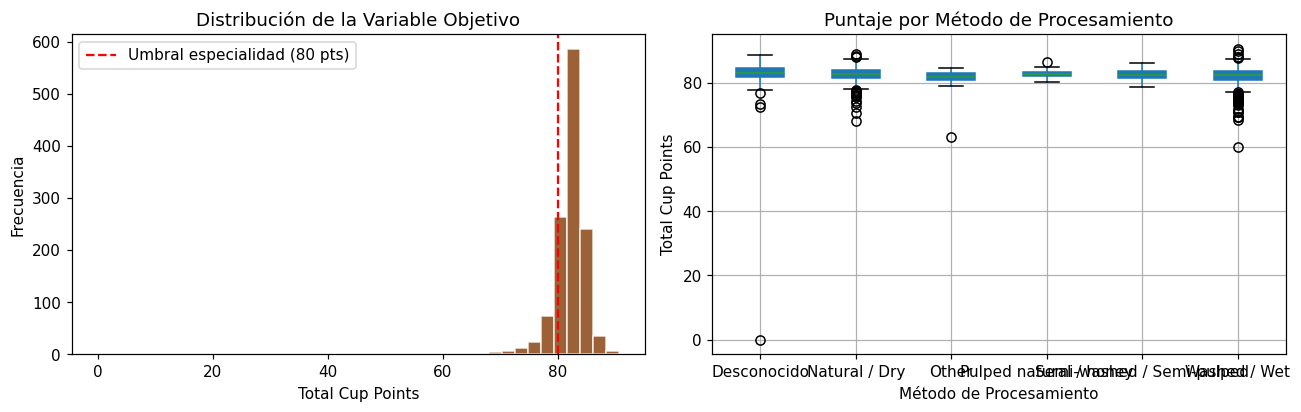

Estadísticos básicos de Total.Cup.Points:
count    1254.000000
mean       82.097002
std         3.542603
min         0.000000
25%        81.170000
50%        82.500000
75%        83.670000
max        90.580000
Name: Total.Cup.Points, dtype: float64


In [218]:
### Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET], bins=40, color='saddlebrown', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Total Cup Points')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de la Variable Objetivo')
axes[0].axvline(80, color='red', linestyle='--', label='Umbral especialidad (80 pts)')
axes[0].legend()

# Boxplot por método de procesamiento
order = df.groupby('Processing.Method')[TARGET].median().sort_values(ascending=False).index
df.boxplot(column=TARGET, by='Processing.Method', ax=axes[1],
           vert=True, patch_artist=True)
axes[1].set_xlabel('Método de Procesamiento')
axes[1].set_ylabel('Total Cup Points')
axes[1].set_title('Puntaje por Método de Procesamiento')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fig1_distribucion_objetivo.png', bbox_inches='tight')
plt.show()
print(f"Estadísticos básicos de {TARGET}:")
print(df[TARGET].describe())

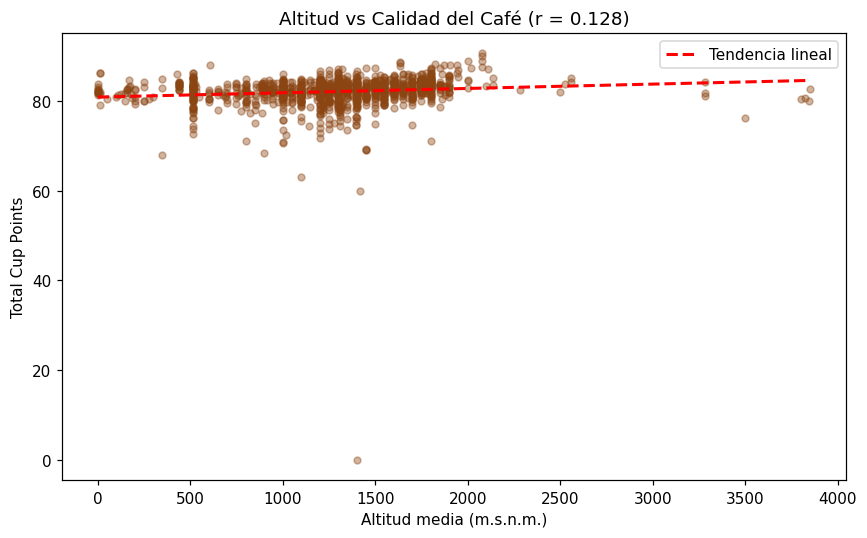

In [219]:
# Relación altitud vs puntaje
fig, ax = plt.subplots(figsize=(8, 5))
# Filtrar outliers de altitud
alt_mask = (df['altitude_mean_meters'] > 0) & (df['altitude_mean_meters'] < 4000)
ax.scatter(df.loc[alt_mask, 'altitude_mean_meters'],
           df.loc[alt_mask, TARGET],
           alpha=0.4, color='saddlebrown', s=20)
# Línea de tendencia
x = df.loc[alt_mask, 'altitude_mean_meters']
y = df.loc[alt_mask, TARGET]
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
xs = np.linspace(x.min(), x.max(), 200)
ax.plot(xs, p(xs), 'r--', linewidth=2, label=f'Tendencia lineal')
corr = x.corr(y)
ax.set_xlabel('Altitud media (m.s.n.m.)')
ax.set_ylabel('Total Cup Points')
ax.set_title(f'Altitud vs Calidad del Café (r = {corr:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('fig2_altitud_vs_calidad.png', bbox_inches='tight')
plt.show()

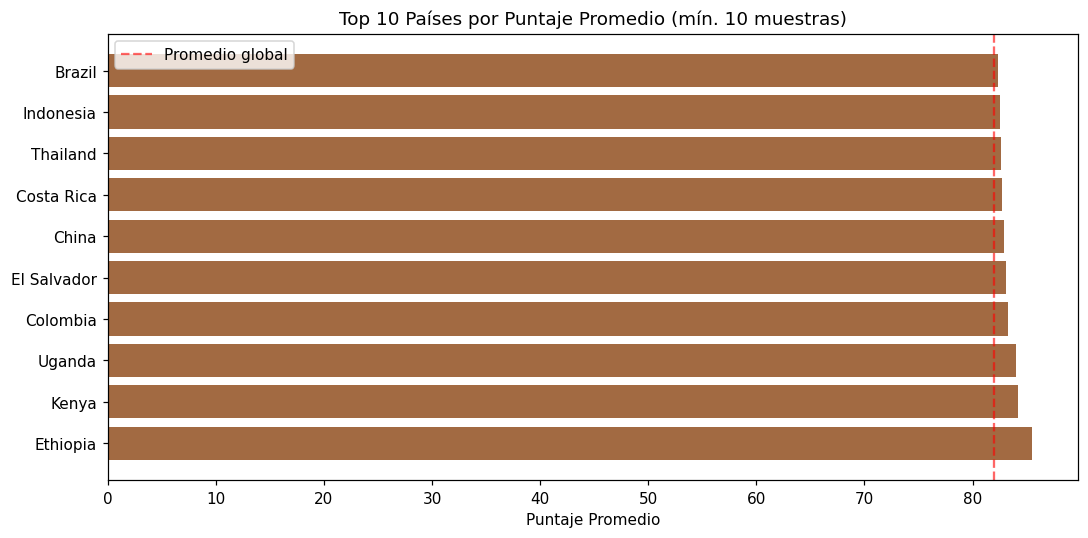

In [220]:
# Top 10 países por puntaje promedio
country_stats = df.groupby('Country.of.Origin')[TARGET].agg(['mean', 'count'])
country_stats = country_stats[country_stats['count'] >= 10].sort_values('mean', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(country_stats.index, country_stats['mean'], color='saddlebrown', alpha=0.8)
ax.set_xlabel('Puntaje Promedio')
ax.set_title('Top 10 Países por Puntaje Promedio (mín. 10 muestras)')
ax.axvline(82, color='red', linestyle='--', alpha=0.6, label='Promedio global')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_top_paises.png', bbox_inches='tight')
plt.show()

## 2. Preprocesamiento

### Implementacion One-Hot Encoding.

In [221]:
# Definir la lista de columnas categóricas a transformar
columnas_categoricas = ['Country.of.Origin', 'Region', 'Processing.Method', 'Color']

# Aplicar One-Hot Encoding
# Se utiliza drop_first=True para eliminar la primera categoría de cada variable.
# Esto es fundamental para evitar la trampa de la multicolinealidad,
df_modelado = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True, dtype=int)

# Validar el impacto de la transformación en las dimensiones del dataset
print("Dimensiones antes de la codificación:", df.shape)
print("Dimensiones después de la codificación:", df_modelado.shape)

# Mostrar una vista previa de las nuevas columnas generadas
df_modelado.head()

Dimensiones antes de la codificación: (1254, 10)
Dimensiones después de la codificación: (1254, 391)


,altitude_mean_meters,Category.One.Defects,Category.Two.Defects,Number.of.Bags,Moisture,Total.Cup.Points,Country.of.Origin_Burundi,Country.of.Origin_China,Country.of.Origin_Colombia,Country.of.Origin_Costa Rica,...,Region_苗栗三灣,Region_苗栗泰安,Processing.Method_Natural / Dry,Processing.Method_Other,Processing.Method_Pulped natural / honey,Processing.Method_Semi-washed / Semi-pulped,Processing.Method_Washed / Wet,Color_Bluish-Green,Color_Desconocido,Color_Green
0,2075.0,0,0,300,0.12,90.58,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
1,2075.0,0,1,300,0.12,89.92,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,2000.0,0,2,320,0.11,89.00,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,2075.0,0,2,300,0.12,88.83,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
7,1635.0,0,0,300,0.03,88.67,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


### Implementacion SMOTE

In [222]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Separar características (X) y objetivo continuo (y)
X = df_modelado.drop('Total.Cup.Points', axis=1)
y = df_modelado['Total.Cup.Points']

# 2. DIVISIÓN DE DATOS (Estrictamente ANTES de SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Estrategia de SMOTE para Regresión
# Unimos temporalmente el puntaje continuo a X_train para que SMOTE cree valores para él
X_train_temp = X_train.copy()
X_train_temp['Puntaje_Continuo'] = y_train

# Creamos una etiqueta categórica temporal
# Usamos 80 puntos como umbral estándar para "Café de Especialidad"
y_train_class = np.where(y_train < 80, 'Baja_Calidad', 'Alta_Calidad')

# 4. Aplicar SMOTE
# Usamos k_neighbors=3 en caso de que haya muy pocos cafés de baja calidad
smote = SMOTE(random_state=42, k_neighbors=3)
X_resampled_temp, y_resampled_class = smote.fit_resample(X_train_temp, y_train_class)

# 5. Separar nuevamente X e y (ahora balanceados y listos para regresión)
y_train_balanced = X_resampled_temp['Puntaje_Continuo']
X_train_balanced = X_resampled_temp.drop('Puntaje_Continuo', axis=1)

# 6. Verificación de resultados
print("=== IMPACTO DEL BALANCEO CON SMOTE ===")
print(f"Tamaño de X_train ORIGINAL: {X_train.shape[0]} muestras")
print(f"Tamaño de X_train BALANCEADO: {X_train_balanced.shape[0]} muestras")
print(f"Nuevos cafés sintéticos generados: {X_train_balanced.shape[0] - X_train.shape[0]}")

=== IMPACTO DEL BALANCEO CON SMOTE ===
Tamaño de X_train ORIGINAL: 1003 muestras
Tamaño de X_train BALANCEADO: 1724 muestras
Nuevos cafés sintéticos generados: 721


In [223]:
# Eliminar fila con Total.Cup.Points == 0 (outlier obvio)
df = df[df[TARGET] > 50].copy()

# Separar X e y
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identificar tipos de columnas
CAT_COLS = ['Country.of.Origin', 'Processing.Method', 'Color']
NUM_COLS = ['altitude_mean_meters', 'Category.One.Defects',
            'Category.Two.Defects', 'Number.of.Bags', 'Moisture']

# Pipeline de preprocesamiento
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, NUM_COLS),
    ('cat', cat_transformer, CAT_COLS)
])

print(f'Dataset limpio: {X.shape[0]} muestras, {X.shape[1]} variables originales')

Dataset limpio: 1253 muestras, 9 variables originales


## 3. Reducción de Dimensión — Análisis Individual de Variables

Correlación de variables numéricas con la variable objetivo:
                      Correlación con Total Cup Points
Number.of.Bags                                0.036999
altitude_mean_meters                         -0.016112
Category.One.Defects                         -0.150659
Moisture                                     -0.154911
Category.Two.Defects                         -0.287800


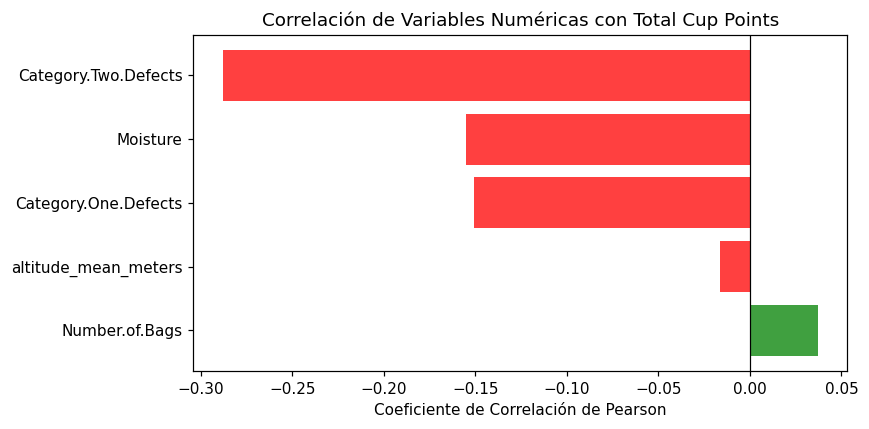

In [224]:
# Correlación de variables numéricas con el target
corr_df = df[NUM_COLS + [TARGET]].corr()[[TARGET]].drop(TARGET)
corr_df.columns = ['Correlación con Total Cup Points']
corr_df = corr_df.sort_values('Correlación con Total Cup Points', ascending=False)
print('Correlación de variables numéricas con la variable objetivo:')
print(corr_df)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if v > 0 else 'red' for v in corr_df.iloc[:, 0]]
ax.barh(corr_df.index, corr_df.iloc[:, 0], color=colors, alpha=0.75)
ax.set_xlabel('Coeficiente de Correlación de Pearson')
ax.set_title('Correlación de Variables Numéricas con Total Cup Points')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('fig4_correlaciones.png', bbox_inches='tight')
plt.show()

In [225]:
# Varianza de la variable objetivo por categoría (eta-cuadrado aproximado)
def eta_squared(groups, target):
    """Índice de discriminación eta^2 para variables categóricas."""
    grand_mean = target.mean()
    ss_total = ((target - grand_mean)**2).sum()
    ss_between = sum(
        len(g) * (g.mean() - grand_mean)**2
        for g in [target[groups == cat] for cat in groups.unique()]
    )
    return ss_between / ss_total

for col in CAT_COLS:
    eta = eta_squared(df[col].fillna('Unknown'), y)
    print(f'{col:30s}  η² = {eta:.4f}')

Country.of.Origin               η² = 0.2102
Processing.Method               η² = 0.0194
Color                           η² = 0.0089


In [226]:
# Función de evaluación con IC bootstrap
def eval_model(estimator, X, y, cv=5, n_bootstrap=200):
    """
    Retorna métricas de CV + intervalos de confianza bootstrap.
    """
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    results = cross_validate(
        estimator, X, y, cv=kf,
        scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
        return_train_score=True
    )
    rmse_scores = -results['test_neg_root_mean_squared_error']
    mae_scores  = -results['test_neg_mean_absolute_error']
    r2_scores   = results['test_r2']
    rmse_train  = -results['train_neg_root_mean_squared_error']

    def ci95(arr):
        boot = [np.mean(np.random.choice(arr, size=len(arr), replace=True))
                for _ in range(n_bootstrap)]
        return np.percentile(boot, [2.5, 97.5])

    return {
        'RMSE_val':   rmse_scores.mean(),
        'RMSE_ci':    ci95(rmse_scores),
        'MAE_val':    mae_scores.mean(),
        'R2_val':     r2_scores.mean(),
        'R2_ci':      ci95(r2_scores),
        'RMSE_train': rmse_train.mean(),
    }

print('Función de evaluación definida.')

Función de evaluación definida.


In [227]:
# ─── Definición de modelos y grillas de hiperparámetros ───
#
# Modelo 1: Ridge Regression (paramétrico / regresión lineal regularizada)
# Modelo 2: KNN Regressor (no paramétrico)
# Modelo 3: Random Forest (ensemble de árboles)
# Modelo 4: Gradient Boosting (ensemble de árboles, estilo XGBoost)
# Modelo 5: MLP Neural Network (red neuronal artificial)
# Modelo 6: SVR (máquina de vectores de soporte)

# Tabla de hiperparámetros analizados
HYPERPARAM_TABLE = pd.DataFrame([
    ['Ridge',             'alpha',           '0.01, 0.1, 1, 10, 100, 1000'],
    ['KNN',               'n_neighbors',     '3, 5, 7, 10, 15, 20'],
    ['KNN',               'weights',         'uniform, distance'],
    ['Random Forest',     'n_estimators',    '50, 100, 200'],
    ['Random Forest',     'max_depth',       'None, 5, 10, 20'],
    ['Random Forest',     'min_samples_leaf','1, 3, 5'],
    ['Gradient Boosting', 'n_estimators',    '50, 100, 200'],
    ['Gradient Boosting', 'learning_rate',   '0.01, 0.05, 0.1, 0.2'],
    ['Gradient Boosting', 'max_depth',       '3, 5, 7'],
    ['MLP',               'hidden_layer_sizes','(50,), (100,), (100,50), (100,100)'],
    ['MLP',               'alpha (L2)',      '0.0001, 0.001, 0.01'],
    ['MLP',               'learning_rate_init','0.001, 0.01'],
    ['SVR',               'C',               '0.1, 1, 10, 100'],
    ['SVR',               'epsilon',         '0.1, 0.5, 1.0'],
    ['SVR',               'kernel',          'rbf, linear'],
], columns=['Modelo', 'Hiperparámetro', 'Valores evaluados'])

In [228]:
# ─── GridSearchCV para cada modelo ───
# Se usa CV interno de 3-fold para búsqueda de hiperparámetros
# y CV externo de 5-fold para estimación del desempeño final.

def make_pipeline(model):
    return Pipeline([('prep', preprocessor), ('model', model)])

inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

# 1. Ridge
ridge_gs = GridSearchCV(
    make_pipeline(Ridge()),
    param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

# 2. KNN
knn_gs = GridSearchCV(
    make_pipeline(KNeighborsRegressor()),
    param_grid={'model__n_neighbors': [3, 5, 7, 10, 15, 20],
                'model__weights': ['uniform', 'distance']},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

# 3. Random Forest
rf_gs = GridSearchCV(
    make_pipeline(RandomForestRegressor(random_state=42)),
    param_grid={'model__n_estimators': [100, 200],
                'model__max_depth': [None, 10, 20],
                'model__min_samples_leaf': [1, 3, 5]},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

# 4. Gradient Boosting
gb_gs = GridSearchCV(
    make_pipeline(GradientBoostingRegressor(random_state=42)),
    param_grid={'model__n_estimators': [100, 200],
                'model__learning_rate': [0.05, 0.1, 0.2],
                'model__max_depth': [3, 5]},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

# 5. MLP
mlp_gs = GridSearchCV(
    make_pipeline(MLPRegressor(max_iter=500, random_state=42, early_stopping=True)),
    param_grid={'model__hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100)],
                'model__alpha': [0.0001, 0.001, 0.01]},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

# 6. SVR
svr_gs = GridSearchCV(
    make_pipeline(SVR()),
    param_grid={'model__C': [1, 10, 100],
                'model__epsilon': [0.1, 0.5, 1.0],
                'model__kernel': ['rbf', 'linear']},
    cv=inner_cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)

MODELS = {
    'Ridge (paramétrico)':          ridge_gs,
    'KNN (no paramétrico)':         knn_gs,
    'Random Forest (ensemble)':     rf_gs,
    'Gradient Boosting (ensemble)': gb_gs,
    'Red Neuronal (MLP)':           mlp_gs,
    'SVR':                          svr_gs,
}
print('Modelos y grillas de búsqueda configurados.')

Modelos y grillas de búsqueda configurados.


In [ ]:
# ─── Evaluación con CV externo (5-fold) ───
# Esto puede tardar algunos minutos.
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
results_all = {}

for name, estimator in MODELS.items():
    print(f'Evaluando {name}...', end=' ')
    res = eval_model(estimator, X, y, cv=5)
    results_all[name] = res
    print(f'RMSE={res["RMSE_val"]:.4f}  R²={res["R2_val"]:.4f}')

print('\n✅ Evaluación completada.')

Evaluando Ridge (paramétrico)... RMSE=2.3855  R²=0.1946
Evaluando KNN (no paramétrico)... RMSE=2.4213  R²=0.1733
Evaluando Random Forest (ensemble)... RMSE=2.3573  R²=0.2117
Evaluando Gradient Boosting (ensemble)... RMSE=2.3984  R²=0.1859
Evaluando Red Neuronal (MLP)... 

In [ ]:
# ─── Tabla de resultados ───
rows = []
for name, r in results_all.items():
    rows.append({
        'Modelo': name,
        'RMSE Train': f"{r['RMSE_train']:.4f}",
        'RMSE Val': f"{r['RMSE_val']:.4f}",
        'RMSE IC 95%': f"[{r['RMSE_ci'][0]:.4f}, {r['RMSE_ci'][1]:.4f}]",
        'MAE Val': f"{r['MAE_val']:.4f}",
        'R² Val': f"{r['R2_val']:.4f}",
        'R² IC 95%': f"[{r['R2_ci'][0]:.4f}, {r['R2_ci'][1]:.4f}]",
    })

results_df = pd.DataFrame(rows)
print('Tabla 1. Resultados de los modelos (validación cruzada 5-fold):')
results_df

In [ ]:
# ─── Gráfica comparativa de RMSE con IC ───
names = list(results_all.keys())
rmse_vals = [results_all[n]['RMSE_val'] for n in names]
rmse_lows = [results_all[n]['RMSE_val'] - results_all[n]['RMSE_ci'][0] for n in names]
rmse_highs= [results_all[n]['RMSE_ci'][1] - results_all[n]['RMSE_val'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
axes[0].barh(names, rmse_vals, xerr=[rmse_lows, rmse_highs],
             color='saddlebrown', alpha=0.75, capsize=4)
axes[0].set_xlabel('RMSE')
axes[0].set_title('RMSE de Validación (5-fold CV) con IC 95%')

# R²
r2_vals = [results_all[n]['R2_val'] for n in names]
r2_lows  = [results_all[n]['R2_val'] - results_all[n]['R2_ci'][0] for n in names]
r2_highs = [results_all[n]['R2_ci'][1] - results_all[n]['R2_val'] for n in names]
axes[1].barh(names, r2_vals, xerr=[r2_lows, r2_highs],
             color='olivedrab', alpha=0.75, capsize=4)
axes[1].set_xlabel('R²')
axes[1].set_title('R² de Validación (5-fold CV) con IC 95%')

plt.tight_layout()
plt.savefig('fig5_comparacion_modelos.png', bbox_inches='tight')
plt.show()

In [ ]:
# ─── Efecto de hiperparámetros: Random Forest (ejemplo detallado) ───
from sklearn.model_selection import validation_curve

pipe_rf = make_pipeline(RandomForestRegressor(random_state=42))
n_est_range = [10, 50, 100, 200, 300]
train_scores, val_scores = validation_curve(
    pipe_rf, X, y,
    param_name='model__n_estimators',
    param_range=n_est_range,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_est_range, -train_scores.mean(axis=1), 'o-', label='Train RMSE', color='navy')
ax.fill_between(n_est_range,
                -train_scores.mean(axis=1) - train_scores.std(axis=1),
                -train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color='navy')
ax.plot(n_est_range, -val_scores.mean(axis=1), 's-', label='Val RMSE', color='saddlebrown')
ax.fill_between(n_est_range,
                -val_scores.mean(axis=1) - val_scores.std(axis=1),
                -val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color='saddlebrown')
ax.set_xlabel('Número de Árboles (n_estimators)')
ax.set_ylabel('RMSE')
ax.set_title('Curva de Validación — Random Forest')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_validation_curve_rf.png', bbox_inches='tight')
plt.show()

In [ ]:
# ─── Curva de aprendizaje del mejor modelo ───
from sklearn.model_selection import learning_curve

# Entrenar el mejor estimador primero para identificarlo
best_name = min(results_all, key=lambda n: results_all[n]['RMSE_val'])
print(f'Mejor modelo: {best_name}')

best_estimator = MODELS[best_name]
best_estimator.fit(X, y)
best_pipeline = best_estimator.best_estimator_

train_sizes, train_sc, val_sc = learning_curve(
    best_pipeline, X, y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, -train_sc.mean(axis=1), 'o-', label='Train RMSE', color='navy')
ax.plot(train_sizes, -val_sc.mean(axis=1), 's-', label='Val RMSE', color='saddlebrown')
ax.fill_between(train_sizes,
                -val_sc.mean(axis=1) - val_sc.std(axis=1),
                -val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.2, color='saddlebrown')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('RMSE')
ax.set_title(f'Curva de Aprendizaje — {best_name}')
ax.legend()
plt.tight_layout()
plt.savefig('fig7_learning_curve.png', bbox_inches='tight')
plt.show()

In [ ]:
# ─── Predicciones vs valores reales (mejor modelo) ───
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(
    best_pipeline, X, y,
    cv=KFold(n_splits=5, shuffle=True, random_state=42)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter pred vs real
axes[0].scatter(y, y_pred_cv, alpha=0.4, color='saddlebrown', s=15)
lims = [min(y.min(), y_pred_cv.min()), max(y.max(), y_pred_cv.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1)
axes[0].set_xlabel('Valor real (Total Cup Points)')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title(f'Predicciones vs Valores Reales — {best_name}')

# Residuos
residuals = y - y_pred_cv
axes[1].hist(residuals, bins=40, color='olivedrab', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Residuo (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')

plt.tight_layout()
plt.savefig('fig8_pred_vs_real.png', bbox_inches='tight')
plt.show()

print(f'RMSE final CV: {np.sqrt(mean_squared_error(y, y_pred_cv)):.4f}')
print(f'MAE  final CV: {mean_absolute_error(y, y_pred_cv):.4f}')
print(f'R²   final CV: {r2_score(y, y_pred_cv):.4f}')

In [ ]:
# Transformar datos para reducción de dimensión
X_transformed = preprocessor.fit_transform(X)
print(f'Dimensiones tras preprocesamiento: {X_transformed.shape}')

In [ ]:
# Análisis de varianza explicada
pca_full = PCA().fit(X_transformed)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, 'o-', color='saddlebrown')
ax.axhline(0.90, color='red', linestyle='--', label='90% varianza')
ax.axhline(0.95, color='orange', linestyle='--', label='95% varianza')
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
ax.axvline(n_90, color='red', alpha=0.4)
ax.axvline(n_95, color='orange', alpha=0.4)
ax.set_xlabel('Número de Componentes Principales')
ax.set_ylabel('Varianza Explicada Acumulada')
ax.set_title('Varianza Explicada por PCA')
ax.legend()
plt.tight_layout()
plt.savefig('fig9_pca_varianza.png', bbox_inches='tight')
plt.show()

print(f'Componentes para 90% varianza: {n_90}')
print(f'Componentes para 95% varianza: {n_95}')
print(f'Reducción con 90%: {(1 - n_90/X_transformed.shape[1])*100:.1f}%')

In [ ]:
# ─── Criterio de selección: 90% de varianza explicada ───
N_COMPONENTS_PCA = n_90

# Identificar los 2 mejores modelos
ranked = sorted(results_all.items(), key=lambda x: x[1]['RMSE_val'])
top2_names = [ranked[0][0], ranked[1][0]]
print(f'Top 2 modelos: {top2_names}')

# Pipeline con PCA
def make_pca_pipeline(base_pipeline, n_components):
    """Inserta PCA después del preprocesador."""
    return Pipeline([
        ('prep', preprocessor),
        ('pca', PCA(n_components=n_components, random_state=42)),
        ('model', base_pipeline.named_steps['model'])
    ])

pca_results = {}
for name in top2_names:
    gs = MODELS[name]
    # Ajustar si aún no tiene best_estimator_
    if not hasattr(gs, 'best_estimator_'):
        gs.fit(X, y)
    pca_pipe = make_pca_pipeline(gs.best_estimator_, N_COMPONENTS_PCA)
    res = eval_model(pca_pipe, X, y, cv=5)
    pca_results[name + ' + PCA'] = res
    print(f'{name} + PCA  RMSE={res["RMSE_val"]:.4f}  R²={res["R2_val"]:.4f}')

print('\nReducción de dimensión aplicada.')

In [ ]:
# Tabla comparativa original vs PCA
pca_comparison = []
for name in top2_names:
    r_orig = results_all[name]
    r_pca  = pca_results[name + ' + PCA']
    pca_comparison.append({
        'Modelo': name,
        'RMSE Original': f"{r_orig['RMSE_val']:.4f}",
        'R² Original':   f"{r_orig['R2_val']:.4f}",
        'RMSE + PCA':    f"{r_pca['RMSE_val']:.4f}",
        'R² + PCA':      f"{r_pca['R2_val']:.4f}",
        '% Reducción':   f"{(1 - N_COMPONENTS_PCA/X_transformed.shape[1])*100:.1f}%",
    })
pd.DataFrame(pca_comparison)

In [ ]:
# t-SNE para visualización (2 componentes)
print('Ejecutando t-SNE 2D...')
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500)
X_tsne_2d = tsne_2d.fit_transform(X_transformed)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1],
                c=y, cmap='RdYlGn', alpha=0.6, s=15)
plt.colorbar(sc, ax=ax, label='Total Cup Points')
ax.set_xlabel('t-SNE Componente 1')
ax.set_ylabel('t-SNE Componente 2')
ax.set_title('Visualización t-SNE — coloreado por calidad del café')
plt.tight_layout()
plt.savefig('fig10_tsne_2d.png', bbox_inches='tight')
plt.show()
print('t-SNE completado.')

In [ ]:
from sklearn.decomposition import KernelPCA

# KernelPCA (rbf) como extracción no lineal — funciona en pipelines
N_COMPONENTS_KPCA = 10  # mismo criterio que PCA lineal
tsne_results = {}  # renombramos para mantener compatibilidad con el resto del código

for name in top2_names:
    gs = MODELS[name]
    if not hasattr(gs, 'best_estimator_'):
        gs.fit(X, y)

    kpca_pipe = Pipeline([
        ('prep', preprocessor),
        ('kpca', KernelPCA(n_components=N_COMPONENTS_KPCA, kernel='rbf', random_state=42)),
        ('scaler2', StandardScaler()),
        ('model', gs.best_estimator_.named_steps['model'])
    ])
    res = eval_model(kpca_pipe, X, y, cv=5)
    tsne_results[name + ' + KernelPCA'] = res
    print(f'{name} + KernelPCA({N_COMPONENTS_KPCA}D)  RMSE={res["RMSE_val"]:.4f}  R²={res["R2_val"]:.4f}')

In [ ]:
# Tabla resumen reducción no lineal
kpca_comparison = []
for name in top2_names:
    r_orig = results_all[name]
    r_kpca = tsne_results[name + ' + KernelPCA']
    kpca_comparison.append({
        'Modelo': name,
        'RMSE Original': f"{r_orig['RMSE_val']:.4f}",
        'R² Original':   f"{r_orig['R2_val']:.4f}",
        f'RMSE + KernelPCA({N_COMPONENTS_KPCA})': f"{r_kpca['RMSE_val']:.4f}",
        f'R² + KernelPCA({N_COMPONENTS_KPCA})':   f"{r_kpca['R2_val']:.4f}",
        '% Reducción': f"{(1 - N_COMPONENTS_KPCA/X_transformed.shape[1])*100:.1f}%",
    })
pd.DataFrame(kpca_comparison)

In [ ]:
from sklearn.decomposition import KernelPCA

# KernelPCA (rbf) como extracción no lineal — funciona en pipelines
N_COMPONENTS_KPCA = 10  # mismo criterio que PCA lineal
tsne_results = {}  # renombramos para mantener compatibilidad con el resto del código

for name in top2_names:
    gs = MODELS[name]
    if not hasattr(gs, 'best_estimator_'):
        gs.fit(X, y)

    kpca_pipe = Pipeline([
        ('prep', preprocessor),
        ('kpca', KernelPCA(n_components=N_COMPONENTS_KPCA, kernel='rbf', random_state=42)),
        ('scaler2', StandardScaler()),
        ('model', gs.best_estimator_.named_steps['model'])
    ])
    res = eval_model(kpca_pipe, X, y, cv=5)
    tsne_results[name + ' + KernelPCA'] = res
    print(f'{name} + KernelPCA({N_COMPONENTS_KPCA}D)  RMSE={res["RMSE_val"]:.4f}  R²={res["R2_val"]:.4f}')

In [ ]:
# Tabla resumen reducción no lineal
kpca_comparison = []
for name in top2_names:
    r_orig = results_all[name]
    r_kpca = tsne_results[name + ' + KernelPCA']
    kpca_comparison.append({
        'Modelo': name,
        'RMSE Original': f"{r_orig['RMSE_val']:.4f}",
        'R² Original':   f"{r_orig['R2_val']:.4f}",
        f'RMSE + KernelPCA({N_COMPONENTS_KPCA})': f"{r_kpca['RMSE_val']:.4f}",
        f'R² + KernelPCA({N_COMPONENTS_KPCA})':   f"{r_kpca['R2_val']:.4f}",
        '% Reducción': f"{(1 - N_COMPONENTS_KPCA/X_transformed.shape[1])*100:.1f}%",
    })
pd.DataFrame(kpca_comparison)

# importancia de variables


In [ ]:
# Ajustar el mejor modelo completo para extraer importancias
best_model_name = ranked[0][0]
best_full = MODELS[best_model_name]
best_full.fit(X, y)
final_pipeline = best_full.best_estimator_

# Obtener nombres de features tras OHE
ohe = final_pipeline.named_steps['prep'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(CAT_COLS).tolist()
all_feature_names = NUM_COLS + cat_feature_names

model_step = final_pipeline.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
    top20 = feat_imp.head(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    top20.plot.barh(ax=ax, color='saddlebrown', alpha=0.8)
    ax.invert_yaxis()
    ax.set_xlabel('Importancia relativa')
    ax.set_title(f'Top 20 Variables Más Importantes — {best_model_name}')
    plt.tight_layout()
    plt.savefig('fig11_feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    # Para Ridge: usar coeficientes
    if hasattr(model_step, 'coef_'):
        coefs = np.abs(model_step.coef_)
        feat_imp = pd.Series(coefs, index=all_feature_names).sort_values(ascending=False)
        top20 = feat_imp.head(20)
        fig, ax = plt.subplots(figsize=(9, 7))
        top20.plot.barh(ax=ax, color='saddlebrown', alpha=0.8)
        ax.invert_yaxis()
        ax.set_xlabel('|Coeficiente|')
        ax.set_title(f'Coeficientes del Modelo — {best_model_name}')
        plt.tight_layout()
        plt.savefig('fig11_feature_importance.png', bbox_inches='tight')
        plt.show()
    else:
        print('Este modelo no expone importancias directas. Considera usar permutation_importance.')

# conclusiones

In [ ]:
# Resumen final de todos los experimentos
summary_rows = []
for name, r in results_all.items():
    summary_rows.append({'Configuración': name, 'RMSE': r['RMSE_val'], 'R²': r['R2_val']})
for name, r in pca_results.items():
    summary_rows.append({'Configuración': name, 'RMSE': r['RMSE_val'], 'R²': r['R2_val']})
for name, r in tsne_results.items():
    summary_rows.append({'Configuración': name, 'RMSE': r['RMSE_val'], 'R²': r['R2_val']})

summary_df = pd.DataFrame(summary_rows).sort_values('RMSE')
print('=== RESUMEN FINAL DE RESULTADOS ===')
summary_df.to_string(index=False, float_format='%.4f')
print(summary_df.to_string(index=False, float_format='%.4f'))